# Single-Target QSAR: Predicting Biological Activity (pIC50) for BACE1 and hERG

*Benchmarking the classical ECFP4 + tree pipeline on two therapeutically relevant targets, and confronting the specific challenges of bioactivity data: assay noise and activity cliffs.*

## Abstract

The physicochemical notebooks predicted intrinsic molecular properties; here the target becomes biological activity (pIC50), which is assay-dependent and noisier. The same ECFP4 + descriptor pipeline (with one added flexibility descriptor) and tree-based models are benchmarked on two targets: BACE1 (Alzheimer's disease, n = 1513, MoleculeNet) and hERG (cardiotoxicity, n = 8348, curated from ChEMBL). On BACE1, XGBoost reaches R2 = 0.72 (RMSE 0.71) under repeated cross-validation and RMSE 0.85 under a scaffold split, which beats the published random-forest benchmark (1.07) and approaches the D-MPNN graph network (0.791). On hERG, tree models plateau at RMSE ~0.58, close to the ~0.5 log inter-laboratory noise floor, and a blocker/non-blocker classifier reaches AUC 0.70. An activity-cliff analysis finds that 4.2% of structurally similar BACE1 pairs differ by more than two pIC50 units, imposing a hard ceiling on any structure-based model. Hyperparameter tuning yields only a marginal gain (RMSE 0.697 to 0.675), confirming that data quality, not model choice, is the limiting factor.

## 1. Introduction

Quantitative structure-activity relationship (QSAR) modelling seeks to predict a molecule's biological activity directly from its structure. This is a shift from the previous notebooks: aqueous solubility or hydration free energy are intrinsic physicochemical properties with a single reproducible value, whereas biological activity is measured as an IC50 (the concentration inhibiting 50% of a target's function) in a specific assay against a specific protein. The activity is reported as pIC50 = -log10(IC50 in mol/L), so that larger values mean more potent compounds (pIC50 = 9 corresponds to 1 nM, pIC50 = 6 to 1 uM).

This assay dependence introduces noise sources absent from physicochemical properties: inter-laboratory variability, differences in assay conditions, and compound artifacts such as aggregation. Inter-laboratory reproducibility for IC50 measurements is of the order of 0.5 log units, which sets a floor below which no model can improve, and it means data from different sources can only be pooled after careful curation (a single measurement type, consistent units, deduplication). Bioactivity is also affected by activity cliffs: pairs of structurally very similar molecules with markedly different potency, which violate the core QSAR assumption that similar structures have similar activity.

Two targets are studied. BACE1 (beta-secretase 1) is a protease implicated in the production of amyloid-beta peptides in Alzheimer's disease and a long-standing drug target [Subramanian et al., 2016]. hERG is a cardiac potassium channel whose inadvertent blockade prolongs the QT interval and can cause fatal arrhythmia, making hERG liability prediction a central safety filter in drug discovery [Sanguinetti & Tristani-Firouzi, 2006]. Published regression benchmarks on BACE1 (scaffold split) include a random forest at RMSE 1.07 and the D-MPNN graph network at 0.791 [Yang et al., 2019]; hERG regression benchmarks vary widely across datasets and curation choices.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 80     # reduit la taille affichee de TOUTES les figures
plt.rcParams["font.size"] = 9       # texte compact mais lisible
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 8

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RepeatedKFold, KFold, cross_validate, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from collections import defaultdict
from xgboost import XGBRegressor

print("Libraries imported.")

Libraries imported.


## 2. Data

### 2.1 BACE1 (MoleculeNet)

BACE1 is loaded from the MoleculeNet distribution. Only the SMILES (column `mol`), the regression target `pIC50`, and the classification label `Class` are used; the numerous precomputed descriptor columns are ignored so that features are computed consistently with the earlier notebooks.

In [3]:
bace_url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/bace.csv"
df_bace = pd.read_csv(bace_url)
print("BACE1 shape:", df_bace.shape)
print("BAC1 columns:", df_bace.columns.tolist())

BACE1 shape: (1513, 595)
BAC1 columns: ['mol', 'CID', 'Class', 'Model', 'pIC50', 'MW', 'AlogP', 'HBA', 'HBD', 'RB', 'HeavyAtomCount', 'ChiralCenterCount', 'ChiralCenterCountAllPossible', 'RingCount', 'PSA', 'Estate', 'MR', 'Polar', 'sLi_Key', 'ssBe_Key', 'ssssBem_Key', 'sBH2_Key', 'ssBH_Key', 'sssB_Key', 'ssssBm_Key', 'sCH3_Key', 'dCH2_Key', 'ssCH2_Key', 'tCH_Key', 'dsCH_Key', 'aaCH_Key', 'sssCH_Key', 'ddC_Key', 'tsC_Key', 'dssC_Key', 'aasC_Key', 'aaaC_Key', 'ssssC_Key', 'sNH3_Key', 'sNH2_Key', 'ssNH2_Key', 'dNH_Key', 'ssNH_Key', 'aaNH_Key', 'tN_Key', 'sssNH_Key', 'dsN_Key', 'aaN_Key', 'sssN_Key', 'ddsN_Key', 'aasN_Key', 'ssssN_Key', 'daaN_Key', 'sOH_Key', 'dO_Key', 'ssO_Key', 'aaO_Key', 'aOm_Key', 'sOm_Key', 'sF_Key', 'sSiH3_Key', 'ssSiH2_Key', 'sssSiH_Key', 'ssssSi_Key', 'sPH2_Key', 'ssPH_Key', 'sssP_Key', 'dsssP_Key', 'ddsP_Key', 'sssssP_Key', 'sSH_Key', 'dS_Key', 'ssS_Key', 'aaS_Key', 'dssS_Key', 'ddssS_Key', 'ssssssS_Key', 'Sm_Key', 'sCl_Key', 'sGeH3_Key', 'ssGeH2_Key', 'sssGeH_Ke

count    1513.000000
mean        6.521991
std         1.342417
min         2.544546
25%         5.585027
50%         6.761954
75%         7.540000
max        10.522879
Name: pIC50, dtype: float64


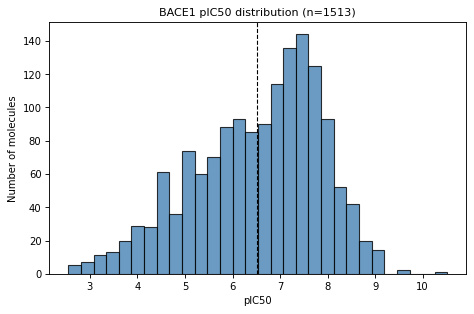

In [11]:
bace_smiles = df_bace["mol"]
bace_y = df_bace["pIC50"]

print(bace_y.describe())

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(bace_y, bins=30, color="steelblue", edgecolor="black", alpha=0.8)
ax.axvline(bace_y.mean(), color="black", linestyle="--", linewidth=1)
ax.set_xlabel("pIC50")
ax.set_ylabel("Number of molecules")
ax.set_title("BACE1 pIC50 distribution (n=1513)")
plt.tight_layout()
plt.show()

The BACE1 pIC50 distribution is broad (2.5 to 10.5) and roughly symmetric, centred near 6.5 (median 6.76) and well populated across its range, with a mild left tail toward weakly active compounds. This is a healthier distribution than the hydration free energies of FreeSolv, with no severely undersampled region. A favourable distribution does not, however, guarantee an easy task: bioactivity carries an irreducible noise floor and, more importantly, activity cliffs that no structure-based model can resolve (quantified in Section 4.3).

### 2.2 hERG (curated from ChEMBL)

No single canonical hERG regression set exists, so the data are extracted directly from ChEMBL (target CHEMBL240) and curated: only IC50 measurements, with an exact relation and biochemical assay type, are retained. Values are kept in nanomolar within a plausible range, converted to pIC50, and deduplicated per molecule by taking the median (which absorbs the inter-laboratory spread into one consensus value).

In [12]:
from chembl_webresource_client.new_client import new_client

activity = new_client.activity
res = activity.filter(
    target_chembl_id="CHEMBL240",   # hERG
    standard_type="IC50",           # un seul type de mesure
    relation="=",                   # valeurs exactes, pas des > ou 
    assay_type="B",                 # assays biochimiques uniquement
).only(["molecule_chembl_id", "canonical_smiles", "standard_value", "standard_units"])

df_herg_raw = pd.DataFrame(res)     # materialise la requete (peut etre long)
print("rows fetched:", len(df_herg_raw))
print(df_herg_raw.columns.tolist())
print(df_herg_raw.head())

rows fetched: 10228
['canonical_smiles', 'molecule_chembl_id', 'standard_units', 'standard_value', 'units', 'value']
                                    canonical_smiles molecule_chembl_id  \
0  O=C1NCCN1CCN1CCC(c2cn(-c3ccccc3)c3ccc(Cl)cc23)CC1       CHEMBL443476   
1   O=C1NCCN1CCN1CCC(c2cn(C3CCCCC3)c3ccc(Cl)cc23)CC1        CHEMBL53661   
2             CCC(CC)c1cn(-c2ccc(F)cc2)c2ccc(Cl)cc12       CHEMBL299390   
3  O=C1NCCN1CCN1CC=C(c2cn(-c3ccc(F)cc3)c3ccc(Cl)c...        CHEMBL12186   
4    O=C1NCCN1CCN1CCC(C2CN(c3ccc(F)cc3)c3ccccc32)CC1       CHEMBL556312   

  standard_units standard_value units   value  
0             nM           88.0    nM    88.0  
1             nM          137.0    nM   137.0  
2             nM         1480.0    nM  1480.0  
3             nM           10.0    nM    10.0  
4             nM           23.5    nM    23.5  


hERG unique molecules: (8348, 2)
count    8348.000000
mean        5.425418
std         0.895448
min         2.078834
25%         4.832683
50%         5.267606
75%         5.824489
max         9.000000
Name: pIC50, dtype: float64


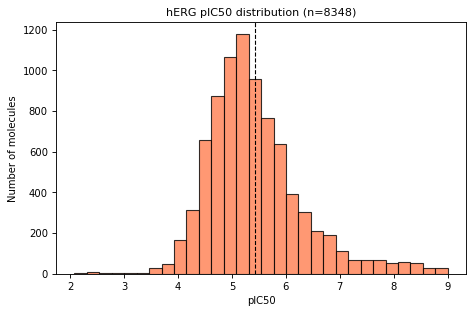

In [15]:
import numpy as np

df = df_herg_raw.copy()

# 1. garder les unites nM
df = df[df["standard_units"] == "nM"]

# 2. valeur numerique (illisibles -> NaN), puis on retire les NaN
df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
df = df.dropna(subset=["standard_value", "canonical_smiles"])

# 3. filtrer les valeurs aberrantes (en nM)
df = df[(df["standard_value"] >= 1) & (df["standard_value"] <= 1e7)]

# 4. conversion en pIC50 (vectorise, pas de boucle)
df["pIC50"] = 9 - np.log10(df["standard_value"])

# 5. dedupliquer par molecule : mediane du pIC50, un SMILES par molecule
df_herg = (df.groupby("molecule_chembl_id")
             .agg(smiles=("canonical_smiles", "first"),
                  pIC50=("pIC50", "median"))
             .reset_index(drop=True))



print("hERG unique molecules:", df_herg.shape)
print(df_herg["pIC50"].describe())

herg_smiles = df_herg["smiles"]
herg_y = df_herg["pIC50"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(herg_y, bins=30, color="coral", edgecolor="black", alpha=0.8)
ax.axvline(herg_y.mean(), color="black", linestyle="--", linewidth=1)
ax.set_xlabel("pIC50")
ax.set_ylabel("Number of molecules")
ax.set_title("hERG pIC50 distribution (n=" + str(len(herg_y)) + ")")
plt.tight_layout()
plt.show()

Curation reduces 10228 raw measurements to 8348 unique molecules. The hERG pIC50 distribution is markedly narrower than BACE1's (standard deviation 0.90 versus 1.34) and centred lower (mean 5.43), reflecting that most tested compounds are weak-to-moderate blockers. The sharp ceiling at exactly 9.0 is an artifact of the 1 nM lower filter, not a biological limit. The combination of a narrow spread and a ~0.5 log noise floor means the variance available to model is small relative to the noise, which will structurally limit the achievable regression R2 on this target.

### 2.3 Dataset comparison

| Dataset | Target | n | mean pIC50 | std | range |
|---|---|---|---|---|---|
| BACE1 | beta-secretase 1 | 1513 | 6.52 | 1.34 | 2.5 - 10.5 |
| hERG | potassium channel | 8348 | 5.43 | 0.90 | 2.1 - 9.0 |

The two datasets present opposite profiles: BACE1 is small but wide-ranging, hERG is large but narrow and closer to its noise floor. Together they probe the pipeline under different data regimes.

## 3. Methods

Molecular representation and models are kept identical to the earlier notebooks so that results reflect the target, not the method. Each molecule is encoded as a 2048-bit ECFP4 Morgan fingerprint concatenated with physicochemical descriptors. One descriptor is added relative to the solubility notebooks: the number of rotatable bonds, motivated by the fact that conformational flexibility affects protein binding differently from solubility. The feature vector is therefore 2055-dimensional. Three models are compared (linear regression, random forest, XGBoost) with the same default hyperparameters as before; parameters are not re-optimised for these datasets, except in the dedicated tuning experiment of Section 4.5. Evaluation uses repeated 5-fold cross-validation and a Bemis-Murcko scaffold split, with the target vector realigned to the molecules whose SMILES parse successfully.

In [18]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'LogP': Descriptors.MolLogP(mol),
        'MolWt': Descriptors.MolWt(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol)
    }

def compute_fingerprint(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits)
    return np.array(fp)

def build_feature_matrix(smiles_series):
    desc_list = smiles_series.apply(compute_descriptors).tolist()
    valid_mask = [d is not None for d in desc_list]
    smiles_valid = smiles_series[valid_mask].reset_index(drop=True)
    descriptors = pd.DataFrame([d for d in desc_list if d is not None])
    fp_matrix = np.array([compute_fingerprint(s) for s in smiles_valid])
    X = np.hstack([fp_matrix, descriptors.values])
    return X, smiles_valid, descriptors

def build_Xy(smiles_series, target_series):
    X, smiles_valid, desc = build_feature_matrix(smiles_series)
    valid_mask = smiles_series.apply(lambda s: Chem.MolFromSmiles(s) is not None).values
    y = target_series[valid_mask].reset_index(drop=True)
    return X, y, smiles_valid, desc

X_bace, y_bace, bace_smiles_valid, bace_desc = build_Xy(bace_smiles, bace_y)
X_herg, y_herg, herg_smiles_valid, herg_desc = build_Xy(herg_smiles, herg_y)

print("BACE  X:", X_bace.shape, "| y:", y_bace.shape, "| dropped:", len(bace_smiles) - X_bace.shape[0])
print("hERG  X:", X_herg.shape, "| y:", y_herg.shape, "| dropped:", len(herg_smiles) - X_herg.shape[0])

BACE  X: (1513, 2055) | y: (1513,) | dropped: 0
hERG  X: (8348, 2055) | y: (8348,) | dropped: 0


In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

In [22]:
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
scoring = {"r2": "r2", "rmse": "neg_root_mean_squared_error"}
cv_pred = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_kfold(X, y, dataset_name):
    print("===", dataset_name, "(RepeatedKFold 5x5) ===")
    for name, model in models.items():
        res = cross_validate(model, X, y, cv=cv, scoring=scoring)
        r2 = res["test_r2"]
        rmse = -res["test_rmse"]
        print(name, "| R2:", round(r2.mean(), 3), "+/-", round(r2.std(), 3),
              "| RMSE:", round(rmse.mean(), 3), "+/-", round(rmse.std(), 3))

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

def scaffold_split(smiles_valid, test_frac=0.2):
    scaffolds = defaultdict(list)
    for i, smi in enumerate(smiles_valid):
        scaffolds[get_scaffold(smi)].append(i)
    # largest scaffolds go to train; rare ones end up in test (hardest case)
    groups = sorted(scaffolds.values(), key=len, reverse=True)
    n_train = int((1 - test_frac) * len(smiles_valid))
    train_idx, test_idx = [], []
    for group in groups:
        if len(train_idx) + len(group) <= n_train:
            train_idx += group
        else:
            test_idx += group
    return np.array(train_idx), np.array(test_idx)

def evaluate_scaffold(X, y, smiles_valid, dataset_name):
    y = np.asarray(y)
    train_idx, test_idx = scaffold_split(smiles_valid)
    print("===", dataset_name, "(scaffold split) ===")
    print("train:", len(train_idx), "| test:", len(test_idx))
    for name, model in models.items():
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        r2 = r2_score(y[test_idx], pred)
        rmse = mean_squared_error(y[test_idx], pred) ** 0.5
        print(name, "| R2:", round(r2, 3), "| RMSE:", round(rmse, 3))

## 4. Results

### 4.1 BACE1

Under repeated cross-validation, XGBoost and random forest perform almost identically (R2 = 0.72, RMSE 0.71), while linear regression collapses to a negative R2: biological activity is strongly non-linear in these descriptors, and only non-linear models capture it. Under the scaffold split the ranking is preserved but performance drops sharply (XGBoost RMSE 0.85, R2 = 0.40). Because the published benchmarks use scaffold splitting, the fair comparison is the scaffold number: XGBoost at 0.85 beats the published random forest (1.07) and approaches the D-MPNN graph network (0.791) [Yang et al., 2019]. Comparing the random-fold score (0.71) to those scaffold benchmarks would be misleading, as the protocols differ. The large gap between random and scaffold evaluation, more pronounced than for physicochemical properties, reflects that medicinal-chemistry series cluster by scaffold, so a held-out scaffold is genuinely outside the training domain.

In [23]:
evaluate_kfold(X_bace, y_bace, "BACE1")
evaluate_scaffold(X_bace, y_bace, bace_smiles_valid, "BACE1")

=== BACE1 (RepeatedKFold 5x5) ===
Linear Regression | R2: -0.725 +/- 0.4 | RMSE: 1.746 +/- 0.198
Random Forest | R2: 0.715 +/- 0.028 | RMSE: 0.713 +/- 0.035
XGBoost | R2: 0.72 +/- 0.027 | RMSE: 0.707 +/- 0.036
=== BACE1 (scaffold split) ===
train: 1210 | test: 303
Linear Regression | R2: -1.811 | RMSE: 1.832
Random Forest | R2: 0.334 | RMSE: 0.891
XGBoost | R2: 0.398 | RMSE: 0.847


### 4.2 hERG

On hERG regression, random forest leads (RMSE 0.578, R2 = 0.58), narrowly ahead of XGBoost, and linear regression does not collapse as it did on BACE1 (R2 = 0.32). This difference is informative: hERG blockade has a partly linear dependence on lipophilicity, a well-documented structure-activity trend, whereas BACE1 potency depends on a specific binding pocket and is more purely non-linear. Crucially, the random-forest RMSE of 0.578 is close to the ~0.5 log inter-laboratory noise floor, so the modest R2 reflects a lack of modellable signal above the noise rather than a deficient model.

Because the continuous signal is noisy, activity was also framed as a binary blocker/non-blocker classification. At a threshold of pIC50 > 5, a random-forest classifier reaches AUC 0.70 (65.7% blockers). Raising the threshold to the more stringent pIC50 > 6 does not improve discrimination (AUC 0.69) and increases the variance of the estimate, because the positive class becomes rarer (19.5%). The threshold is therefore not the limiting factor; the ceiling is the fingerprint representation and the label noise, consistent with the regression result. Reframing a noisy regression as classification does not, by itself, create signal that is not present.

In [24]:
evaluate_kfold(X_herg, y_herg, "hERG")
evaluate_scaffold(X_herg, y_herg, herg_smiles_valid, "hERG")

=== hERG (RepeatedKFold 5x5) ===
Linear Regression | R2: 0.324 +/- 0.043 | RMSE: 0.735 +/- 0.021
Random Forest | R2: 0.583 +/- 0.017 | RMSE: 0.578 +/- 0.016
XGBoost | R2: 0.532 +/- 0.017 | RMSE: 0.612 +/- 0.014
=== hERG (scaffold split) ===
train: 6678 | test: 1670
Linear Regression | R2: -0.388 | RMSE: 0.973
Random Forest | R2: 0.315 | RMSE: 0.683
XGBoost | R2: 0.298 | RMSE: 0.692


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

y_class = (y_herg > 5).astype(int)          # 1 = bloqueur (toxique), 0 = sur

clf = RandomForestClassifier(n_estimators=100, random_state=42)
auc = cross_val_score(clf, X_herg, y_class, cv=5, scoring="roc_auc")

print("hERG classification AUC:", round(auc.mean(), 3), "+/-", round(auc.std(), 3))
print("fraction of blockers:", round(y_class.mean(), 3))

hERG classification AUC: 0.695 +/- 0.011
fraction of blockers: 0.657


In [26]:
from rdkit import DataStructs

y = y_bace.values   # pIC50 alignes avec bace_smiles_valid
fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, 2048)
       for s in bace_smiles_valid]

### 4.3 Activity cliffs (BACE1)

Activity cliffs are pairs of molecules that are structurally similar (Tanimoto similarity above 0.8 on ECFP4) yet differ in potency by more than two pIC50 units. Among the 1544 structurally similar pairs in BACE1, 65 are cliffs, a rate of 4.2%. Expressed against all possible pairs the count looks negligible, but that denominator is dominated by dissimilar molecules and is misleading; the relevant rate is among similar pairs. Each cliff is an error that no structure-based model can avoid, since it maps near-identical inputs to very different outputs, and this holds for graph networks as much as for fingerprint models. These cliffs, concentrated in the tight congeneric series that matter most to medicinal chemists, impose a hard ceiling that explains both the scaffold-split degradation and why even the best published models do not approach zero error on BACE1.

In [29]:
similar_pairs=0
cliffs = 0
n = len(fps)
for i in range(n):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i+1:])  # sim de i a tous les suivants
    for k, sim in enumerate(sims):
        j = i + 1 + k
        if sim > 0.8:
            similar_pairs += 1
            if abs(y[i] - y[j]) > 2:
                cliffs += 1

print("cliffs:", cliffs, "| paires similaires:", similar_pairs,
      "| taux:", round(100 * cliffs / similar_pairs, 1), "%")

cliffs: 65 | paires similaires: 1544 | taux: 4.2 %


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

y_class = (y_herg > 6).astype(int)          # 1 = bloqueur (toxique), 0 = sur

clf = RandomForestClassifier(n_estimators=100, random_state=42)
auc = cross_val_score(clf, X_herg, y_class, cv=5, scoring="roc_auc")

print("hERG classification AUC:", round(auc.mean(), 3), "+/-", round(auc.std(), 3))
print("fraction of blockers:", round(y_class.mean(), 3))

hERG classification AUC: 0.691 +/- 0.082
fraction of blockers: 0.195


### 4.4 Benchmark comparison

| Dataset | Model / method | Protocol | RMSE | R2 |
|---|---|---|---|---|
| BACE1 | Linear Regression | RepeatedKFold 5x5 | 1.75 | -0.73 |
| | Random Forest | RepeatedKFold 5x5 | 0.71 | 0.72 |
| | **XGBoost (this work)** | RepeatedKFold 5x5 | **0.71** | **0.72** |
| | **XGBoost (this work)** | Scaffold split | **0.85** | **0.40** |
| | Random Forest [Yang 2019] | scaffold, reported | 1.07 | - |
| | D-MPNN [Yang 2019] | scaffold, reported | 0.791 | - |
| hERG | Random Forest | RepeatedKFold 5x5 | 0.578 | 0.58 |
| | XGBoost | RepeatedKFold 5x5 | 0.612 | 0.53 |
| | Random Forest | Scaffold split | 0.683 | 0.32 |

No standard published regression benchmark is used for hERG, as literature values depend strongly on the dataset and curation.

### 4.5 Hyperparameter tuning (BACE1)

To test whether the default hyperparameters limited performance, XGBoost was tuned by randomised search with an inner cross-validation on a training split, and evaluated once on a held-out test set never seen during tuning (to avoid optimistically biased scores). The tuned model improved the held-out RMSE only marginally, from 0.697 to 0.675 (about 3%), with deeper but more strongly regularised and slower-learning trees. The small gain confirms that the model was not the bottleneck: the limiting factors are the activity cliffs and the assay noise inherent to the data.

In [31]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error

# 1. test mis de cote, jamais touche pendant le tuning
Xtr, Xte, ytr, yte = train_test_split(X_bace, y_bace, test_size=0.2, random_state=42)

# 2. espace de recherche (plages XGBoost typiques)
param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

# 3. tuning : CV INTERNE sur le TRAIN uniquement
search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=25, cv=3, scoring="neg_root_mean_squared_error",
    random_state=42, n_jobs=-1,
)
search.fit(Xtr, ytr)
print("best params:", search.best_params_)

# 4. evaluation UNIQUE sur le test jamais vu (tuned vs defaut, meme split)
tuned = search.best_estimator_
rmse_tuned = mean_squared_error(yte, tuned.predict(Xte)) ** 0.5
base = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42).fit(Xtr, ytr)
rmse_base = mean_squared_error(yte, base.predict(Xte)) ** 0.5

print("default XGBoost RMSE:", round(rmse_base, 3))
print("tuned   XGBoost RMSE:", round(rmse_tuned, 3))

best params: {'subsample': 0.7, 'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
default XGBoost RMSE: 0.697
tuned   XGBoost RMSE: 0.675


## 5. Discussion

Moving from physicochemical properties to biological activity exposes limits that were absent before. The fingerprint models remain competitive with published graph networks on BACE1 (scaffold RMSE 0.85 versus D-MPNN 0.791), but their errors are dominated by factors the model cannot control. Activity cliffs place a hard ceiling on any structure-based method, since 4.2% of similar BACE1 pairs behave inconsistently with structural similarity, and hyperparameter tuning recovers only a marginal improvement. On hERG, performance sits close to the inter-laboratory noise floor, so the modest R2 and AUC reflect data quality rather than model inadequacy, and reframing the task as classification does not rescue it.

Two consistent patterns emerge. First, the scaffold split is substantially harder than random cross-validation for bioactivity, more so than for physicochemical properties, because medicinal-chemistry datasets are organised into scaffold-defined series and a novel scaffold is genuinely out of domain. Second, the behaviour of the linear model is diagnostic of the underlying structure-activity relationship: its collapse on BACE1 and partial success on hERG reflect a pocket-specific, non-linear determinant in one case and a lipophilicity-driven, partly linear trend in the other.

The limitations are intrinsic to the ligand-based framing. A single assay per target is used, with no three-dimensional information about the binding site and no account of protein flexibility; the models predict potency and a safety endpoint, not clinical efficacy. Structure-based approaches such as docking, which use the protein three-dimensional structure, would be complementary but require a different methodology.

## 6. Conclusion

Applied to biological activity, the classical ECFP4 + tree pipeline remains competitive with published graph networks on BACE1 and provides a usable, if noise-limited, model and classifier for hERG cardiotoxicity. The central finding is that performance is bounded by the data rather than the model: activity cliffs (4.2% of similar BACE1 pairs) and the ~0.5 log assay noise on hERG set ceilings that neither a stronger model nor hyperparameter tuning can break. This reframes the goal of a QSAR study, from maximising a score to understanding and honestly reporting the limits imposed by bioactivity data.

## References

[1] Subramanian, G. et al. Computational modeling of beta-secretase 1 (BACE-1) inhibitors using ligand-based approaches. J. Chem. Inf. Model. 56, 1936-1949 (2016).

[2] Yang, K. et al. Analyzing learned molecular representations for property prediction. J. Chem. Inf. Model. 59, 3370-3388 (2019). DOI: 10.1021/acs.jcim.9b00237

[3] Xiong, Z. et al. Pushing the boundaries of molecular representation for drug discovery with the graph attention mechanism. J. Med. Chem. 63, 8749-8760 (2020). DOI: 10.1021/acs.jmedchem.9b00959

[4] Sanguinetti, M.C. & Tristani-Firouzi, M. hERG potassium channels and cardiac arrhythmia. Nature 440, 463-469 (2006). DOI: 10.1038/nature04710

[5] Wu, Z. et al. MoleculeNet: a benchmark for molecular machine learning. Chem. Sci. 9, 513-530 (2018). DOI: 10.1039/C7SC02664A